In [1]:
import pandas as pd
import numpy as np
import librosa
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load dataset
df = pd.read_csv('audio.csv')
df.set_index('File_Name', inplace=True)

# Initialize lists for features and labels
features = []
labels = []
genders = [] 

# Read WAV files and extract features
for f in df.index:
    file_path = 'data/' + f
    try:
        signal, rate = librosa.load(file_path, sr=None)
        df.at[f, 'length'] = len(signal) / rate
        
        # Extract MFCCs
        mfccs = librosa.feature.mfcc(y=signal, sr=rate, n_mfcc=13)
        mfccs_mean = np.mean(mfccs, axis=1)

        if mfccs_mean.shape[0] == 13:
            features.append(mfccs_mean)
            labels.append(df.at[f, 'Emotion'])  
            genders.append(df.at[f, 'Gender'])  

    except Exception as e:
        print(f"Error processing file {file_path}: {e}")

# Convert features and labels to arrays
X = np.array(features)
y = np.array(labels)
genders = np.array(genders)

# Create a DataFrame
df_features = pd.DataFrame(X)
df_features['Emotion'] = y
df_features['Gender'] = genders

# Oversampling process
gender_distribution = df_features.groupby(['Emotion', 'Gender']).size()
max_count = gender_distribution.max()

# Initialize balanced DataFrame
balanced_df = pd.DataFrame()

for (emotion, gender), count in gender_distribution.items():
    label_df = df_features[(df_features['Emotion'] == emotion) & (df_features['Gender'] == gender)]
    if len(label_df) < max_count:
        label_df = label_df.sample(max_count, replace=True)
        
    balanced_df = pd.concat([balanced_df, label_df], ignore_index=True)

# Check the balanced dataset
print("Balanced dataset distribution:")
print(balanced_df['Emotion'].value_counts())
print(balanced_df['Gender'].value_counts())

Balanced dataset distribution:
Emotion
angry        192
calm         192
disgust      192
fearful      192
happy        192
neutral      192
sad          192
surprised    192
Name: count, dtype: int64
Gender
F    768
M    768
Name: count, dtype: int64


Accuracy: 0.45
Classification Report:
              precision    recall  f1-score   support

       angry       0.77      0.64      0.70        42
        calm       0.43      0.75      0.55        44
     disgust       0.41      0.50      0.45        32
     fearful       0.42      0.53      0.47        32
       happy       0.48      0.38      0.43        34
     neutral       0.17      0.05      0.08        20
         sad       0.36      0.33      0.35        39
   surprised       0.38      0.24      0.30        45

    accuracy                           0.45       288
   macro avg       0.43      0.43      0.42       288
weighted avg       0.45      0.45      0.44       288



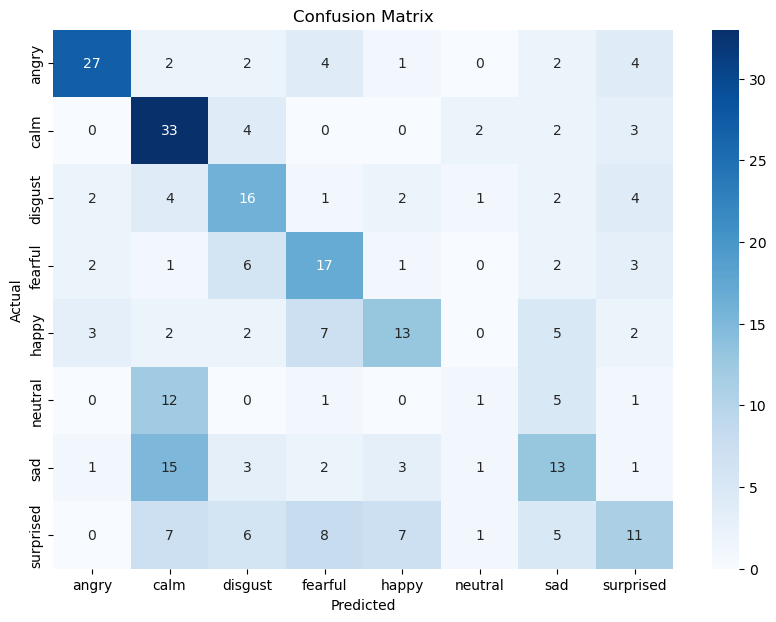

In [5]:
# Assuming df_features has been created and contains the MFCC features, Emotion, and Gender
# Prepare features and labels
X = df_features.drop(columns=['Emotion', 'Gender']).values
y = df_features['Emotion'].values

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the SVM classifier
svm_classifier = SVC(kernel='linear', random_state=42)  # You can also try other kernels like 'rbf'

# Train the classifier
svm_classifier.fit(X_train, y_train)

# Predict on the test set
y_pred = svm_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

# Output the results
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(report)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plotting the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()